# Advanced Exploration Strategies

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare exploration strategies in RL
- Tune exploration for sample efficiency

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 4**.

---


## Lesson Brief

This lesson focuses on how exploration should be balanced, not just turned on or off.

Students will see why too little exploration traps the agent early, while too much exploration slows useful learning.

Why this matters: good RL systems need a balance that changes over time.

This notebook helps students reason about that balance explicitly.

## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Helps students understand the balancing act before focusing on a single heuristic.
- Best when they need the big-picture reasoning behind exploration choices.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


# Advanced Exploration Strategies
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Understand exploration-exploitation trade-off
- Implement Thompson Sampling
- Apply to real-world A/B testing
- Compare exploration strategies

## Real-World Context

Optimizing exploration in recommendation systems, A/B testing, and online learning.

**Industry Impact**: Improves recommendation systems by 10-30%.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy matplotlib scipy -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
from scipy.stats import beta
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Thompson Sampling


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `ThompsonSampling` (what it does): Thompson Sampling for a Bernoulli multi-armed bandit (Beta priors).
class ThompsonSampling:
    """Thompson Sampling for a Bernoulli multi-armed bandit (Beta priors)."""

    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_arms.
    def __init__(self, n_arms: int):
        # Save a value in a name so the next lines can read it.
        self.n_arms = n_arms
        # Beta(1,1) prior per arm
        # Save a value in a name so the next lines can read it.
        self.alpha = np.ones(n_arms)
        # Save a value in a name so the next lines can read it.
        self.beta = np.ones(n_arms)

    # Function `select_arm` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def select_arm(self) -> int:
        # Save a value in a name so the next lines can read it.
        samples = [np.random.beta(self.alpha[i], self.beta[i]) for i in range(self.n_arms)]
        # Send a value back to whoever called this function.
        return int(np.argmax(samples))

    # Function `update` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, arm, reward.
    def update(self, arm: int, reward: float):
        # Rewards here are binary: 1.0 means success and 0.0 means failure.
        # If the condition is True, run the indented block under this line.
        if reward == 1.0:
            # Save a value in a name so the next lines can read it.
            self.alpha[arm] += 1
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            self.beta[arm] += 1


# Demo: 3 arms with hidden Bernoulli success rates (independent per arm; they do not need to sum to 1).
# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
arm_success_rates = np.array([0.35, 0.55, 0.40])
# Save a value in a name so the next lines can read it.
ts = ThompsonSampling(len(arm_success_rates))
# Save a value in a name so the next lines can read it.
pulls = 500
# Start a loop: repeat the indented block once per item in the sequence.
for t in range(pulls):
    # Save a value in a name so the next lines can read it.
    arm = ts.select_arm()
    # Save a value in a name so the next lines can read it.
    r = 1.0 if np.random.rand() < arm_success_rates[arm] else 0.0
    # Execute: ts.update(arm, r)
    ts.update(arm, r)
# Show text or numbers in the cell output area under the code.
print("Estimated arm preferences (alpha / (alpha+beta)):")
# Start a loop: repeat the indented block once per item in the sequence.
for i in range(len(arm_success_rates)):
    # Show text or numbers in the cell output area under the code.
    print(f"  Arm {i}: true p={arm_success_rates[i]:.2f}  posterior mean={ts.alpha[i]/(ts.alpha[i]+ts.beta[i]):.3f}")


Estimated arm preferences (alpha / (alpha+beta)):
  Arm 0: true p=0.35  posterior mean=0.409
  Arm 1: true p=0.55  posterior mean=0.540
  Arm 2: true p=0.40  posterior mean=0.278


## Part 2: A/B Testing Application


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Simulate A/B testing as a two-armed bandit (page A vs page B conversion)
# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(0)
# Save a value in a name so the next lines can read it.
conv_a, conv_b = 0.08, 0.11  # true conversion rates (B is better)
# Save a value in a name so the next lines can read it.
ts_ab = ThompsonSampling(2)
# Save a value in a name so the next lines can read it.
trials = 2000
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(trials):
    # Save a value in a name so the next lines can read it.
    arm = ts_ab.select_arm()
    # Save a value in a name so the next lines can read it.
    p = conv_a if arm == 0 else conv_b
    # Unpack the one-step model output from transition(state, action).
    reward = 1.0 if np.random.rand() < p else 0.0
    # Execute: ts_ab.update(arm, reward)
    ts_ab.update(arm, reward)

# Show text or numbers in the cell output area under the code.
print("A/B test (Thompson Sampling) after", trials, "visitors:")
# Show text or numbers in the cell output area under the code.
print(f"  Arm A (design A) posterior mean: {ts_ab.alpha[0]/(ts_ab.alpha[0]+ts_ab.beta[0]):.3f}  (true {conv_a})")
# Show text or numbers in the cell output area under the code.
print(f"  Arm B (design B) posterior mean: {ts_ab.alpha[1]/(ts_ab.alpha[1]+ts_ab.beta[1]):.3f}  (true {conv_b})")
# Show text or numbers in the cell output area under the code.
print("  → Higher posterior mean ≈ model believes that variant converts better.")


A/B test (Thompson Sampling) after 2000 visitors:
  Arm A (design A) posterior mean: 0.089  (true 0.08)
  Arm B (design B) posterior mean: 0.113  (true 0.11)
  → Higher posterior mean ≈ model believes that variant converts better.


## Real-World Applications

- **E-commerce**: Product recommendation
- **Marketing**: Ad placement optimization
- **Healthcare**: Treatment selection
- **Finance**: Investment strategy selection

---

**End of Notebook**

## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- Thompson Sampling is especially natural for binary success/failure settings like clicks or conversions
- Production experimentation systems are usually richer than this toy setup, but the exploration logic is similar
- In this notebook, the rewards are binary, so the Beta posterior update matches the data cleanly

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


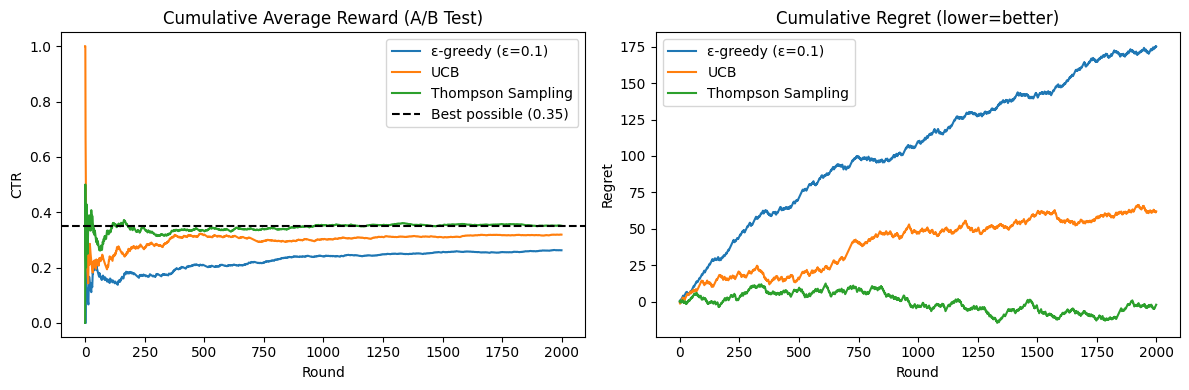


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [4]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Save a value in a name so the next lines can read it.
N_ARMS   = len(TRUE_RATES)
# Save a value in a name so the next lines can read it.
N_ROUNDS = 2000

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand()<eps else np.argmax(totals/(counts+1e-9))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS): r=pull(arm); counts[arm]=1; totals[arm]+=r; rewards.append(r)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        ucb_vals = totals/counts + np.sqrt(2*np.log(t+1)/counts)
        # Save a value in a name so the next lines can read it.
        arm = np.argmax(ucb_vals)
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Save a value in a name so the next lines can read it.
        arm = np.argmax(samples)
        # Save a value in a name so the next lines can read it.
        r = pull(arm)
        # If the condition is True, run the indented block under this line.
        if r: alpha[arm]+=1
        # Else: run this block when none of the if/elif tests above matched.
        else: beta_[arm]+=1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Save a value in a name so the next lines can read it.
strategies = {
    # Save a value in a name so the next lines can read it.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1,len(lst)+1)

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12,4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumavg(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(max(TRUE_RATES), color='k', linestyle='--', label=f"Best possible ({max(TRUE_RATES)})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Save a value in a name so the next lines can read it.
    regret = np.cumsum([max(TRUE_RATES)-pull(np.argmax(TRUE_RATES)) for _ in r]) - np.cumsum(r) + np.cumsum([pull(np.argmax(TRUE_RATES)) for _ in r])
    # Save a value in a name so the next lines can read it.
    regret_simple = np.cumsum(max(TRUE_RATES) - np.array(r))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(regret_simple, label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()
# Show text or numbers in the cell output area under the code.
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

**State-of-the-Art:** ε-greedy and UCB are still dominant in industry A/B testing systems.

## 📝 Summary

You compared **exploration strategies**: ε-greedy (simple, effective), UCB (optimism under uncertainty), and Thompson Sampling (Bayesian). The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


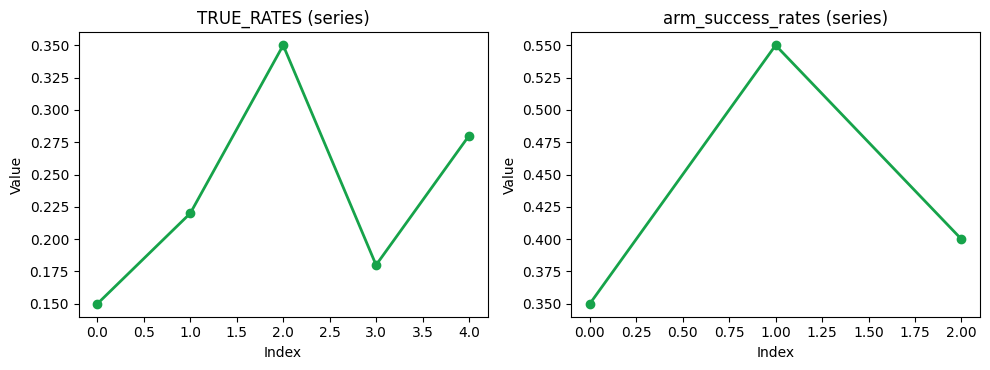

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Good RL systems do not maximize exploration forever or exploit too early; they manage the balance as learning evolves.

**If students remember one idea:** The right balance depends on uncertainty, risk, and how costly mistakes are in the environment.

**Quick check before moving on:**
- Can you explain what goes wrong when exploitation starts too early?
- Can you describe why continued exploration may still matter even after performance improves?

**Bridge to the next step:** This sets up adaptive methods like UCB, which adjust exploration using information gathered so far.
